# Classification Multiclasse des Pneumonies

## Objectif

Après validation du pipeline en classification binaire (Normal vs Pneumonie),
nous étendons l’analyse vers une classification multiclasses :

- Normal
- Pneumonie Bactérienne
- Pneumonie Virale

L’objectif est d’évaluer la capacité du modèle à différencier deux types d’infections pulmonaires radiographiquement proches.

---

## Hypothèse

La distinction entre pneumonie bactérienne et virale sera significativement plus complexe que la simple détection d’anomalie.

Nous anticipons :

- Une baisse initiale des performances
- Une confusion entre Virus et Bacteria
- Une nécessité d’ajustements (class_weight, fine-tuning)

---

## Stratégie

1. Mise en place du modèle EfficientNet multiclasses
2. Entraînement baseline (sans ajustements)
3. Analyse confusion matrix & ROC
4. Ajustement progressif du modèle

In [1]:
import importlib 
import sys
import os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import models

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import data_exploration
importlib.reload(data_exploration)

from model.multiclass_model import build_efficientnet_multiclass, build_efficientnet_head_only
from data_loader_v3 import create_multiclass_generators
from data_exploration import plot_confusion_matrix, plot_multiclass_roc

In [2]:
DATA_DIR = "../chest_Xray"

train_gen, test_gen, val_gen = create_multiclass_generators(DATA_DIR)

print("Classes détectées :", train_gen.class_indices)

print("Train distribution:", np.bincount(train_gen.classes))
print("test distribution:", np.bincount(test_gen.classes))
print("Validation distribution:", np.bincount(val_gen.classes))

Found 3469 images belonging to 3 classes.
Found 867 images belonging to 3 classes.
Found 1402 images belonging to 3 classes.
Classes détectées : {'1_NORMAL': 0, '2_BACTERIA': 1, '3_VIRUS': 2}
Train distribution: [1073 1640  756]
test distribution: [200 688 514]
Validation distribution: [268 410 189]


In [3]:
model = build_efficientnet_multiclass()
# model = build_efficientnet_head_only()

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,219,046 (16.09 MB)

 Trainable params: 2,217,619 (8.46 MB)

 Non-trainable params: 2,001,427 (7.63 MB)

In [4]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

from keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

classes = train_gen.classes

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stopping]
)

{0: np.float64(1.077663870767319), 1: np.float64(0.7050813008130081), 2: np.float64(1.529541446208113)}
Epoch 1/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 61s 494ms/step - accuracy: 0.3154 - loss: 1.9054 - val_accuracy: 0.3345 - val_loss: 1.1906
Epoch 2/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 52s 481ms/step - accuracy: 0.3468 - loss: 1.8325 - val_accuracy: 0.3922 - val_loss: 1.1643
Epoch 3/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 52s 472ms/step - accuracy: 0.3566 - loss: 1.8055 - val_accuracy: 0.4475 - val_loss: 1.1404
Epoch 4/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 58s 531ms/step - accuracy: 0.3670 - loss: 1.7349 - val_accuracy: 0.4960 - val_loss: 1.0924
Epoch 5/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 52s 477ms/step - accuracy: 0.3900 - loss: 1.6702 - val_accuracy: 0.5167 - val_loss: 1.1103
Epoch 6/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 52s 478ms/step - accuracy: 0.4013 - loss: 1.5807 - val_accuracy: 0.5306 - val_loss: 1.0610
Epoch 7/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 52s 480ms/step - accuracy: 0.4093 - loss: 1.5908 - val_accuracy: 0.545

44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 203ms/step
Modèle sauvegardé


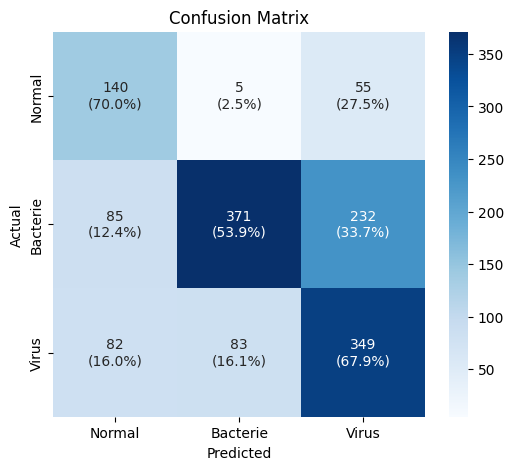


Classification Report:

              precision    recall  f1-score   support

           0       0.46      0.70      0.55       200
           1       0.81      0.54      0.65       688
           2       0.55      0.68      0.61       514

    accuracy                           0.61      1402
   macro avg       0.60      0.64      0.60      1402
weighted avg       0.66      0.61      0.62      1402



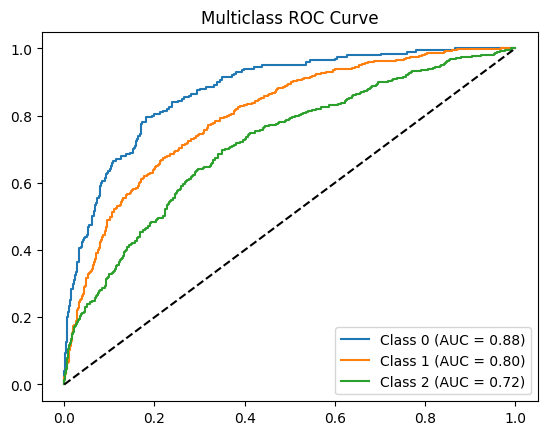

In [10]:
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

print("Modèle sauvegardé")
model.save("efficientnet_multiclass_stage1.keras")

y_pred = np.argmax(y_pred_probs, axis=1)

plot_confusion_matrix(y_true, y_pred)

plot_multiclass_roc(y_true, y_pred_probs, n_classes=3)

### Recharger le meilleur modèle

``` text/plain
model_load = models.load_model("efficientnet_multiclass_stage1.keras")
```

Rechargement du modèle...
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 228ms/step


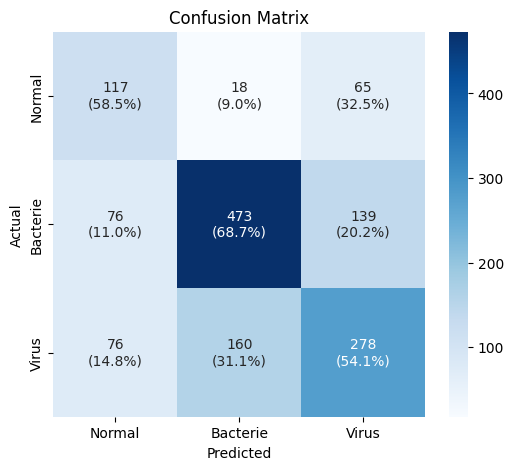


Classification Report:

              precision    recall  f1-score   support

           0       0.43      0.58      0.50       200
           1       0.73      0.69      0.71       688
           2       0.58      0.54      0.56       514

    accuracy                           0.62      1402
   macro avg       0.58      0.60      0.59      1402
weighted avg       0.63      0.62      0.62      1402



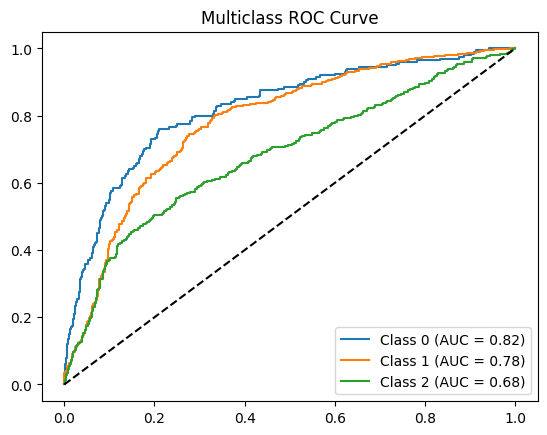

In [7]:
print(f"Rechargement du modèle...")
model_load = models.load_model("efficientnet_multiclass_stage1.keras")

y_true = test_gen.classes

y_pred_probs = model_load.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

plot_confusion_matrix(y_true, y_pred)

plot_multiclass_roc(y_true, y_pred_probs, n_classes=3)